In [ ]:
# Feature Engineering — Outliers & New Features

In [ ]:
# Rebuild Dataset

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 500

neighborhood = rng.choice(['Downtown', 'Suburb', 'Rural'], size=n, p=[0.4, 0.4, 0.2])
house_style = rng.choice(['1Story', '2Story', 'Split'], size=n)
sqft = rng.normal(1800, 500, n).clip(500, 4000)
bedrooms = rng.integers(1, 6, n)
age = rng.integers(0, 80, n)
distance_to_city = rng.normal(15, 8, n).clip(0.5, 60)

neighborhood_premium = {'Downtown': 1.4, 'Suburb': 1.1, 'Rural': 0.8}
style_premium = {'1Story': 1.0, '2Story': 1.15, 'Split': 1.05}

base_price = (sqft * 120 + bedrooms * 8000 - age * 500 - distance_to_city * 900)
price = base_price * np.array([neighborhood_premium[v] for v in neighborhood]) \
              * np.array([style_premium[v] for v in house_style])
price = price + rng.normal(0, 15000, n)

df = pd.DataFrame({
    'neighborhood': neighborhood, 'house_style': house_style,
    'sqft': sqft, 'bedrooms': bedrooms, 'age': age,
    'distance_to_city': distance_to_city, 'price': price
})

# Inject outliers (mansions, extreme commutes, data-entry errors)
outlier_idx = rng.choice(n, size=12, replace=False)
df.loc[outlier_idx[:6], 'sqft'] = rng.uniform(7000, 9000, 6)          # mansion-sized errors
df.loc[outlier_idx[6:], 'distance_to_city'] = rng.uniform(150, 200, 6)  # extreme commute errors
# recompute price for the mansion rows to keep it consistent with sqft
mask = df.index.isin(outlier_idx[:6])
df.loc[mask, 'price'] = df.loc[mask, 'sqft'] * 120 + rng.normal(0, 15000, mask.sum())

df.describe()


,sqft,bedrooms,age,distance_to_city,price
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,1868.650451,3.078000,39.398000,16.466572,2.663629e+05
std,856.366369,1.439465,22.815273,19.956797,1.244366e+05
min,500.000000,1.000000,0.000000,0.500000,5.285566e+02
25%,1474.031775,2.000000,19.000000,9.082019,1.904239e+05
50%,1810.909457,3.000000,38.000000,14.939915,2.550219e+05
75%,2117.877464,4.000000,60.000000,19.811630,3.217123e+05
max,8869.915634,5.000000,79.000000,199.422371,1.101264e+06


In [2]:
# Outlier Detection — IQR Method

numeric_cols = ['sqft', 'bedrooms', 'age', 'distance_to_city', 'price']

def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

print(f"{'Column':<20}{'#Outliers (IQR)':<18}{'Lower':<12}{'Upper'}")
for col in numeric_cols:
    mask, lower, upper = iqr_outliers(df[col])
    print(f"{col:<20}{mask.sum():<18}{lower:<12.1f}{upper:.1f}")


Column              #Outliers (IQR)   Lower       Upper
sqft                12                508.3       3083.6
bedrooms            0                 -1.0        7.0
age                 0                 -42.5       121.5
distance_to_city    10                -7.0        35.9
price               8                 -6508.5     518644.7


In [3]:
# Outlier Detection — Z-Score Method

from scipy import stats

print(f"{'Column':<20}{'#Outliers (|z|>3)'}")
for col in numeric_cols:
    z = np.abs(stats.zscore(df[col]))
    print(f"{col:<20}{(z > 3).sum()}")


Column              #Outliers (|z|>3)
sqft                6
bedrooms            0
age                 0
distance_to_city    6
price               6


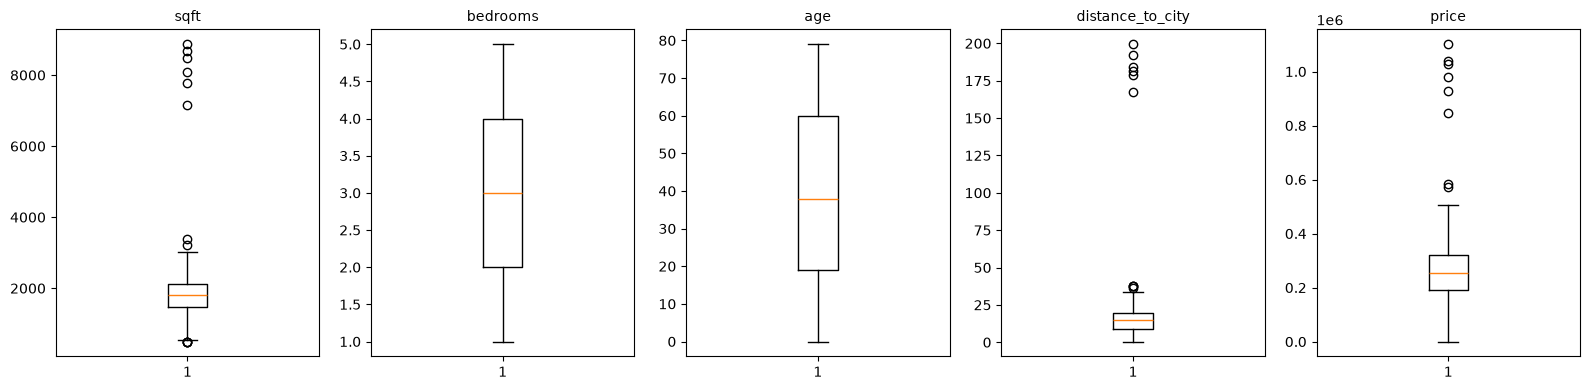

In [4]:
## 4. Boxplots — Visual Confirmation


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col])
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()


In [5]:
# Handling Decision (per feature, with justification)


def cap_outliers(series, lower_q=0.01, upper_q=0.99):
    lower, upper = series.quantile(lower_q), series.quantile(upper_q)
    return series.clip(lower, upper)

df_clean = df.copy()
df_clean['sqft'] = cap_outliers(df_clean['sqft'])
df_clean['distance_to_city'] = cap_outliers(df_clean['distance_to_city'])

print("Before capping - sqft max:", df['sqft'].max().round(1), " | distance max:", df['distance_to_city'].max().round(1))
print("After capping  - sqft max:", df_clean['sqft'].max().round(1), " | distance max:", df_clean['distance_to_city'].max().round(1))


Before capping - sqft max: 8869.9  | distance max: 199.4
After capping  - sqft max: 7156.5  | distance max: 167.8


In [6]:
# New Engineered Features


df_clean['sqft_per_bedroom'] = df_clean['sqft'] / df_clean['bedrooms']
df_clean['is_far_commute'] = (df_clean['distance_to_city'] > 25).astype(int)

df_clean[['sqft', 'bedrooms', 'sqft_per_bedroom', 'distance_to_city', 'is_far_commute']].head()


,sqft,bedrooms,sqft_per_bedroom,distance_to_city,is_far_commute
0,1751.910532,5,350.382106,14.094653,0
1,2364.009429,4,591.002357,6.898529,0
2,659.631077,1,659.631077,16.012774,0
3,1051.680655,5,210.336131,10.330557,0
4,1338.556779,4,334.639195,10.772591,0


In [7]:
# Re-run CV — Before vs After (Day 3 pipeline vs cleaned+engineered)

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

categorical_cols = ['neighborhood', 'house_style']

def make_pipeline(numeric_cols, categorical_cols):
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])
    return Pipeline(steps=[('preprocess', preprocessor), ('model', Ridge(alpha=1.0))])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- BEFORE: raw (uncapped) data, original Day 3 features only ---
numeric_before = ['sqft', 'bedrooms', 'age', 'distance_to_city']
X_before = df[numeric_before + categorical_cols]
y_before = df['price']
pipe_before = make_pipeline(numeric_before, categorical_cols)
cv_before = -cross_val_score(pipe_before, X_before, y_before, cv=kf, scoring='neg_root_mean_squared_error')

# --- AFTER: capped outliers + new engineered features ---
numeric_after = ['sqft', 'bedrooms', 'age', 'distance_to_city', 'sqft_per_bedroom', 'is_far_commute']
X_after = df_clean[numeric_after + categorical_cols]
y_after = df_clean['price']
pipe_after = make_pipeline(numeric_after, categorical_cols)
cv_after = -cross_val_score(pipe_after, X_after, y_after, cv=kf, scoring='neg_root_mean_squared_error')

print(f"{'Version':<35}{'CV Mean RMSE':<15}{'CV Std'}")
print(f"{'BEFORE (raw, outliers present)':<35}{cv_before.mean():<15.2f}{cv_before.std():.2f}")
print(f"{'AFTER (capped + engineered feats)':<35}{cv_after.mean():<15.2f}{cv_after.std():.2f}")
print(f"\nImprovement: {cv_before.mean() - cv_after.mean():.2f} RMSE  "
      f"({100*(cv_before.mean()-cv_after.mean())/cv_before.mean():.1f}% reduction)")


Version                            CV Mean RMSE   CV Std
BEFORE (raw, outliers present)     30625.59       2519.14
AFTER (capped + engineered feats)  28211.36       3535.65

Improvement: 2414.22 RMSE  (7.9% reduction)
